In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

df = pd.read_csv("results.csv")
print(f"{len(df):,} rows, {df['task'].nunique()} tasks, "
      f"context: {sorted(df['context'].unique())}, "
      f"horizon: {sorted(df['horizon'].unique())}")
df.head()

1,267,731 rows, 1739 tasks, context: [np.int64(0), np.int64(512), np.int64(1024), np.int64(1536), np.int64(2048), np.int64(2560), np.int64(3072), np.int64(3584), np.int64(4096)], horizon: [np.int64(0), np.int64(512), np.int64(1024), np.int64(1536), np.int64(2048), np.int64(2560), np.int64(3072), np.int64(3584), np.int64(4096)]


,context,horizon,step,task,actual,predicted
0,0,0,200,Five standard six-sided dice are rolled. We a...,0.125,0.275391
1,0,0,200,Let $f_1(x) = x^2 - 3$ and $f_n(x) = f_1(f_{n-...,0.000,0.718750
2,0,0,200,"Harry, who is incredibly intellectual, needs t...",0.000,0.419922
3,0,0,200,An equilateral triangle with side length $20$ ...,0.000,0.055176
4,0,0,200,"The real numbers $x$, $y$, and $z$ satisfy the...",0.000,0.345703


## MAE Heatmap: Context × Horizon

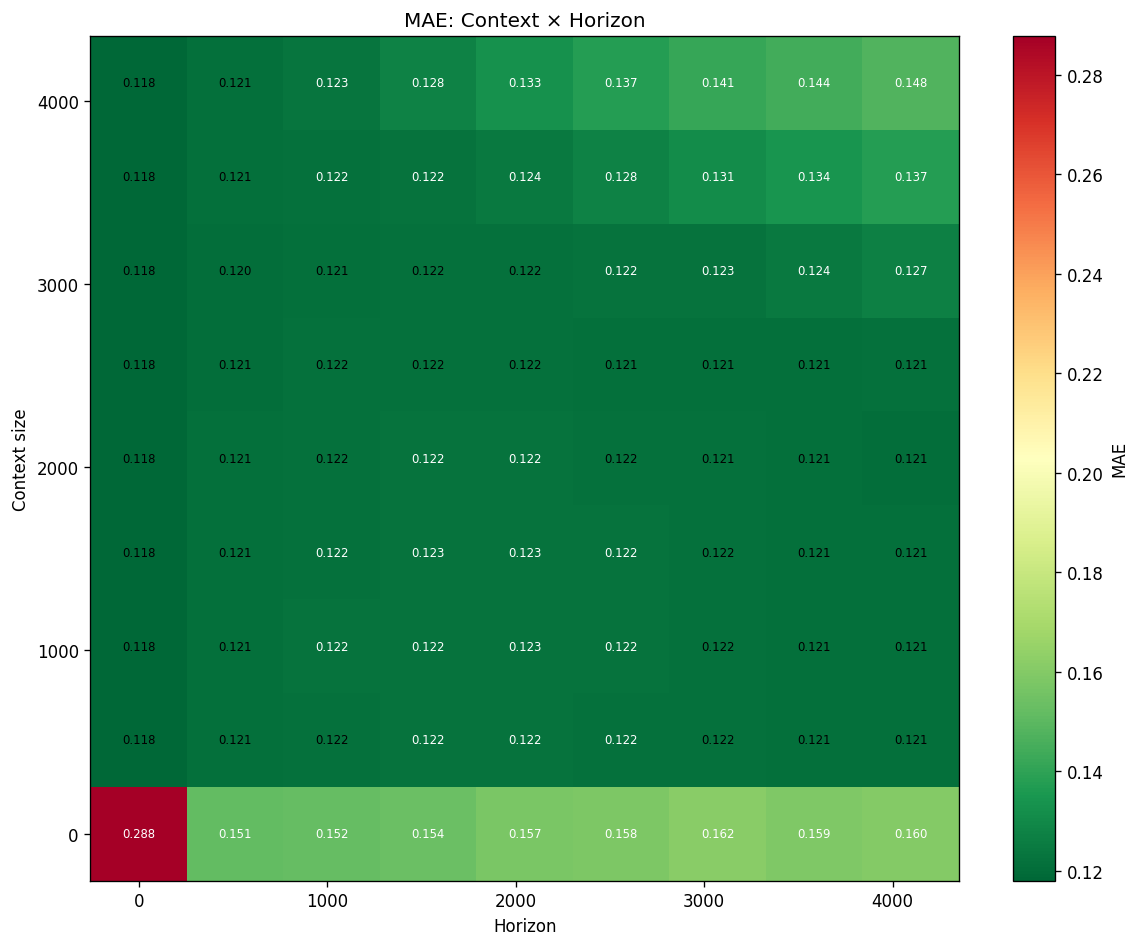

In [2]:
df["error"] = np.abs(df["predicted"] - df["actual"])
mae = df.groupby(["context", "horizon"])["error"].mean().reset_index()
matrix = mae.pivot(index="context", columns="horizon", values="error")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(matrix.columns, matrix.index, matrix.values, cmap="RdYlGn_r", shading="auto")
for i, c in enumerate(matrix.index):
    for j, h in enumerate(matrix.columns):
        val = matrix.loc[c, h]
        if not np.isnan(val):
            ax.text(h, c, f"{val:.3f}", ha="center", va="center", fontsize=7,
                    color="white" if val > np.nanmedian(matrix.values) else "black")
fig.colorbar(im, ax=ax, label="MAE")
ax.set_xlabel("Horizon")
ax.set_ylabel("Context size")
ax.set_title("MAE: Context × Horizon")
fig.tight_layout()

## MAE vs Context (horizon=0) and vs Horizon (context=0)

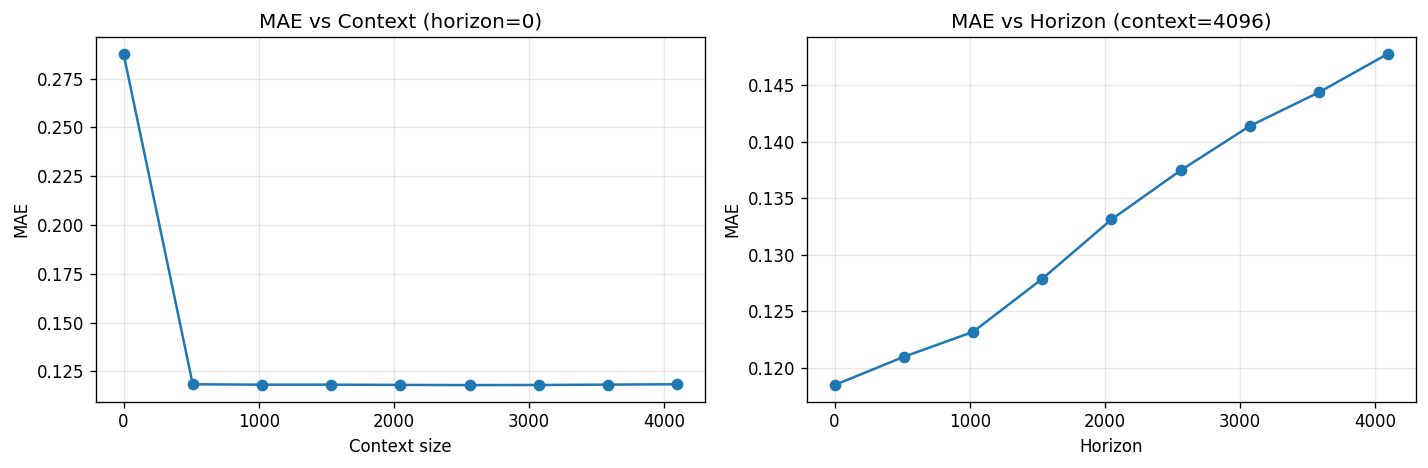

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# MAE vs context (horizon=0)
ctx = df[df["horizon"] == 0].groupby("context")["error"].mean()
ax1.plot(ctx.index, ctx.values, "o-")
ax1.set_xlabel("Context size")
ax1.set_ylabel("MAE")
ax1.set_title("MAE vs Context (horizon=0)")
ax1.grid(alpha=0.3)

# MAE vs horizon (context=0)
hor = df[df["context"] == 4096].groupby("horizon")["error"].mean()
ax2.plot(hor.index, hor.values, "o-")
ax2.set_xlabel("Horizon")
ax2.set_ylabel("MAE")
ax2.set_title("MAE vs Horizon (context=4096)")
ax2.grid(alpha=0.3)

fig.tight_layout()

## Scatter: Predicted vs Actual (selected context sizes, horizon=0)

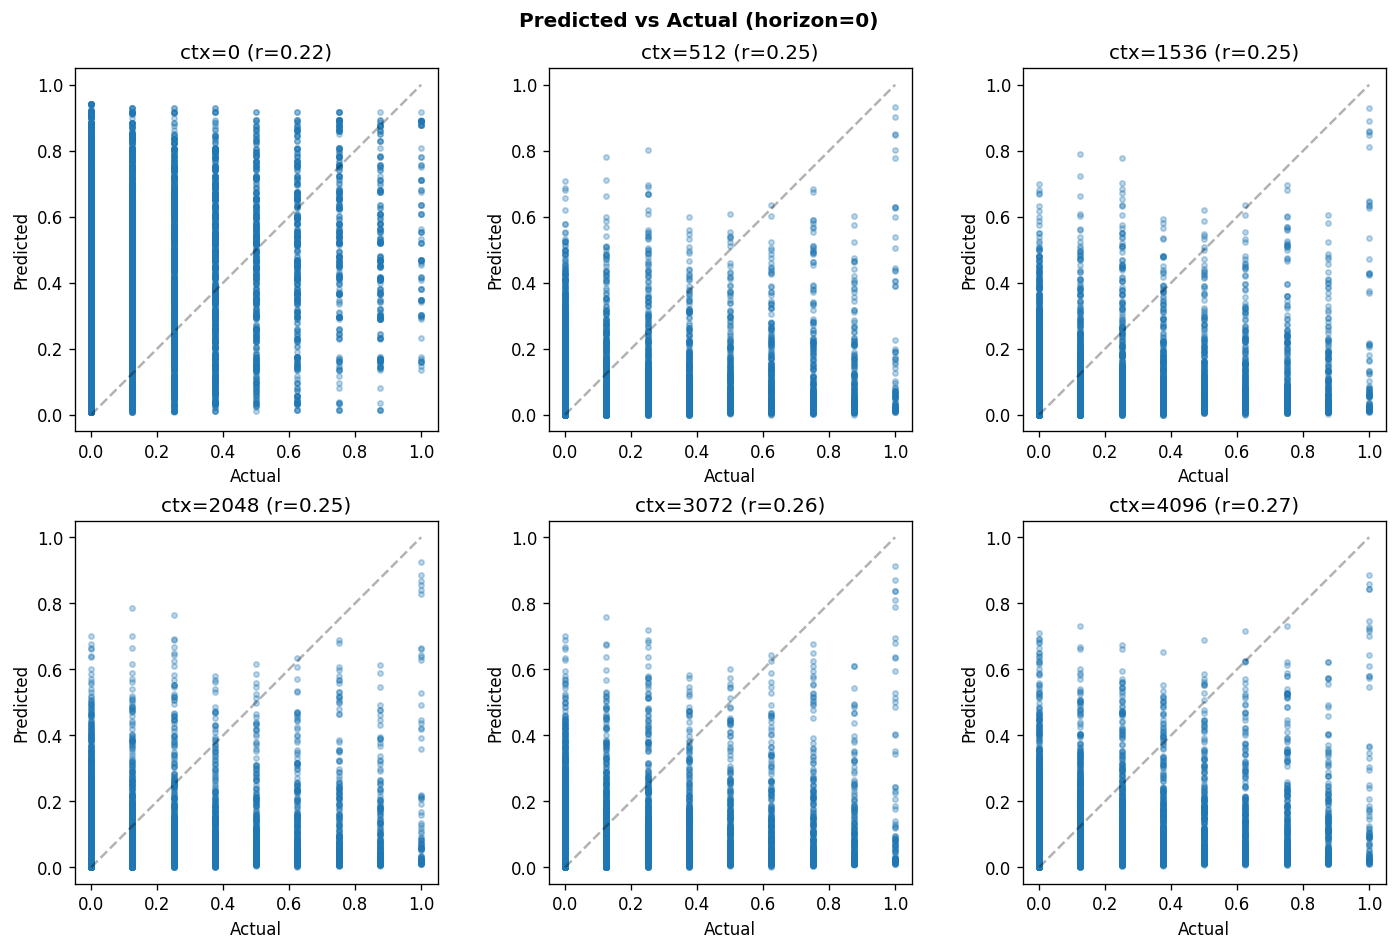

In [4]:
sub = df[df["horizon"] == 0]
contexts = sorted(sub["context"].unique())
# Pick up to 6 evenly spaced context sizes
if len(contexts) > 6:
    idx = np.linspace(0, len(contexts) - 1, 6, dtype=int)
    contexts = [contexts[i] for i in idx]

n = len(contexts)
cols = min(n, 3)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
for i, c in enumerate(contexts):
    ax = axes[i // cols][i % cols]
    d = sub[sub["context"] == c]
    ax.scatter(d["actual"], d["predicted"], alpha=0.3, s=10)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    r = np.corrcoef(d["actual"], d["predicted"])[0, 1]
    ax.set_title(f"ctx={c} (r={r:.2f})")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect("equal")
for i in range(n, rows * cols):
    axes[i // cols][i % cols].set_visible(False)
fig.suptitle("Predicted vs Actual (horizon=0)", fontweight="bold")
fig.tight_layout()

## Calibration: Binned predicted vs actual mean

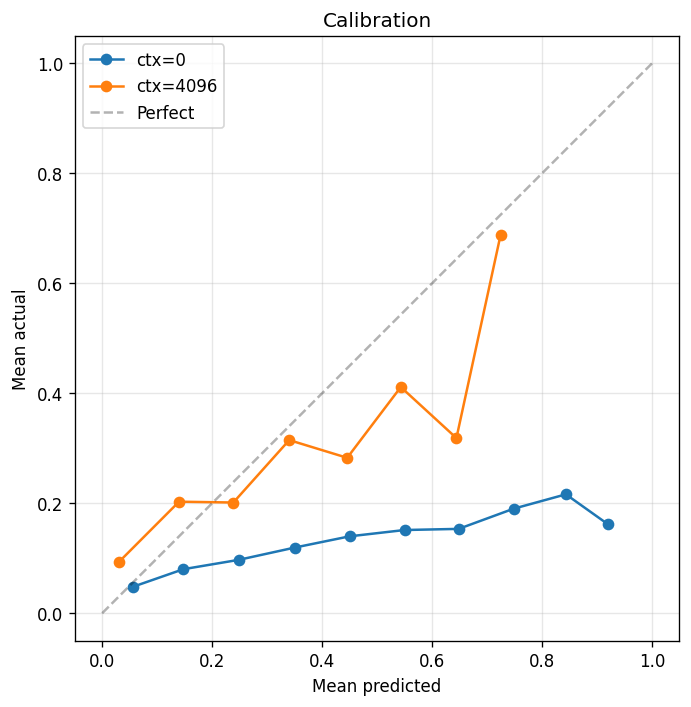

In [5]:
sub = df[df["horizon"] == 0]
contexts = sorted(sub["context"].unique())
max_ctx = contexts[-1]

fig, ax = plt.subplots(figsize=(6, 6))
for c in [0, max_ctx]:
    d = sub[sub["context"] == c]
    bins = np.linspace(0, 1, 11)
    d = d.copy()
    d["bin"] = pd.cut(d["predicted"], bins=bins, include_lowest=True)
    cal = d.groupby("bin", observed=True).agg(
        pred_mean=("predicted", "mean"),
        actual_mean=("actual", "mean"),
        count=("actual", "count"),
    )
    cal = cal[cal["count"] >= 5]
    ax.plot(cal["pred_mean"], cal["actual_mean"], "o-", label=f"ctx={c}", markersize=6)

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect")
ax.set_xlabel("Mean predicted")
ax.set_ylabel("Mean actual")
ax.set_title("Calibration")
ax.legend()
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.grid(alpha=0.3)
fig.tight_layout()

## Kendall Tau vs Context

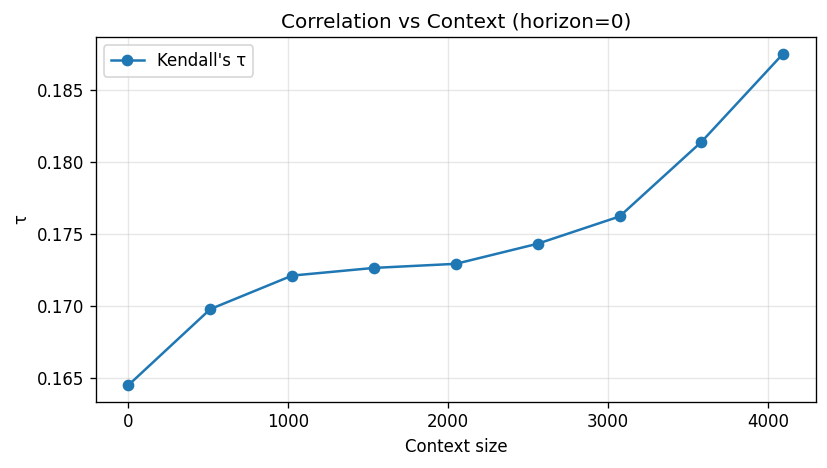

In [23]:
sub = df[df["horizon"] == 0]

tau = []
contexts = sorted(sub["context"].unique())
for c in contexts:
    d = sub[sub["context"] == c]
    tau.append(stats.kendalltau(d["actual"], d["predicted"]).statistic)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(contexts, tau, "o-", label="Kendall's τ")
ax.set_xlabel("Context size")
ax.set_ylabel("τ")
ax.set_title("Correlation vs Context (horizon=0)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## Error distribution by actual outcome bucket

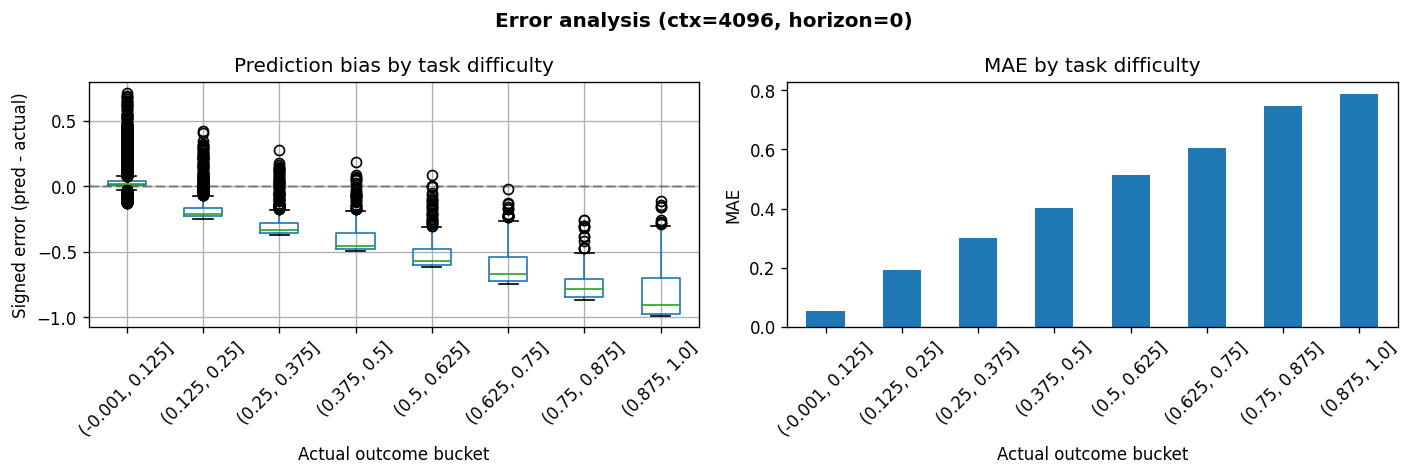

In [7]:
# How does prediction error vary by task difficulty?
sub = df[(df["horizon"] == 0) & (df["context"] == df["context"].max())]
sub = sub.copy()
sub["signed_error"] = sub["predicted"] - sub["actual"]
sub["actual_bin"] = pd.cut(sub["actual"], bins=np.linspace(0, 1, 9), include_lowest=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Signed error by bucket
sub.boxplot(column="signed_error", by="actual_bin", ax=ax1, rot=45)
ax1.axhline(0, color="k", ls="--", alpha=0.3)
ax1.set_xlabel("Actual outcome bucket")
ax1.set_ylabel("Signed error (pred - actual)")
ax1.set_title("Prediction bias by task difficulty")
plt.sca(ax1)
plt.title("Prediction bias by task difficulty")

# MAE by bucket
mae_by_bin = sub.groupby("actual_bin", observed=True)["error"].mean()
mae_by_bin.plot(kind="bar", ax=ax2)
ax2.set_xlabel("Actual outcome bucket")
ax2.set_ylabel("MAE")
ax2.set_title("MAE by task difficulty")
ax2.tick_params(axis="x", rotation=45)

fig.suptitle(f"Error analysis (ctx={int(sub['context'].iloc[0])}, horizon=0)", fontweight="bold")
fig.tight_layout()

## Per-task prediction consistency across context sizes

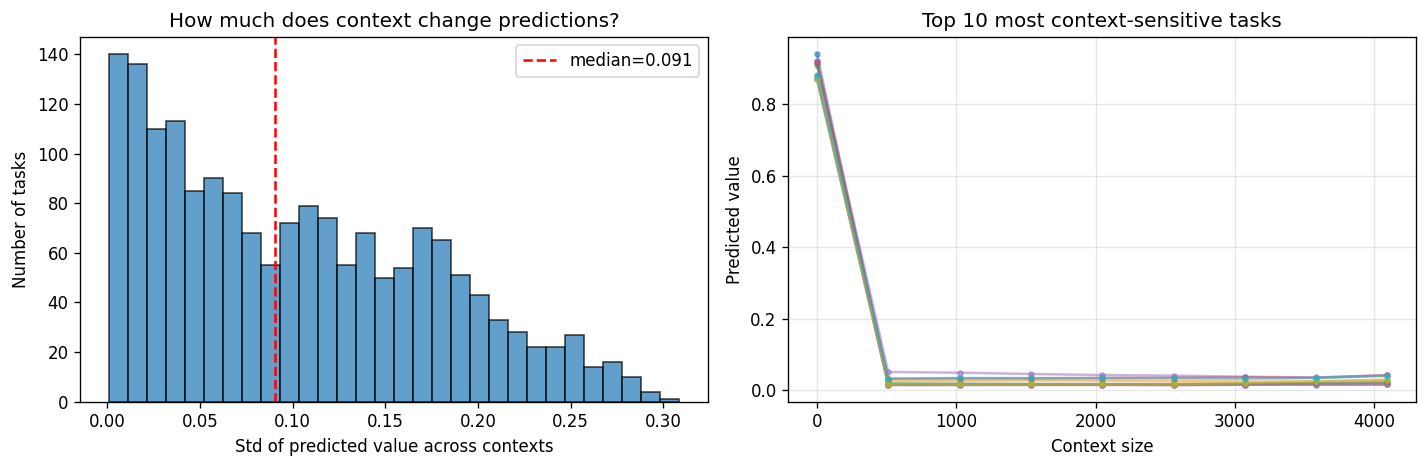

In [8]:
# How much does the prediction for each task change as we add context?
sub = df[df["horizon"] == 0]
task_preds = sub.pivot_table(index="task", columns="context", values="predicted")

# Standard deviation of each task's prediction across context sizes
task_std = task_preds.std(axis=1).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(task_std, bins=30, edgecolor="black", alpha=0.7)
ax1.set_xlabel("Std of predicted value across contexts")
ax1.set_ylabel("Number of tasks")
ax1.set_title("How much does context change predictions?")
ax1.axvline(task_std.median(), color="red", ls="--", label=f"median={task_std.median():.3f}")
ax1.legend()

# Show the most context-sensitive tasks: predicted vs context
top_tasks = task_std.head(10).index
for task in top_tasks:
    row = task_preds.loc[task]
    ax2.plot(row.index, row.values, "o-", alpha=0.5, markersize=3)
ax2.set_xlabel("Context size")
ax2.set_ylabel("Predicted value")
ax2.set_title("Top 10 most context-sensitive tasks")
ax2.grid(alpha=0.3)

fig.tight_layout()

## Outcome distribution: Actual vs Predicted

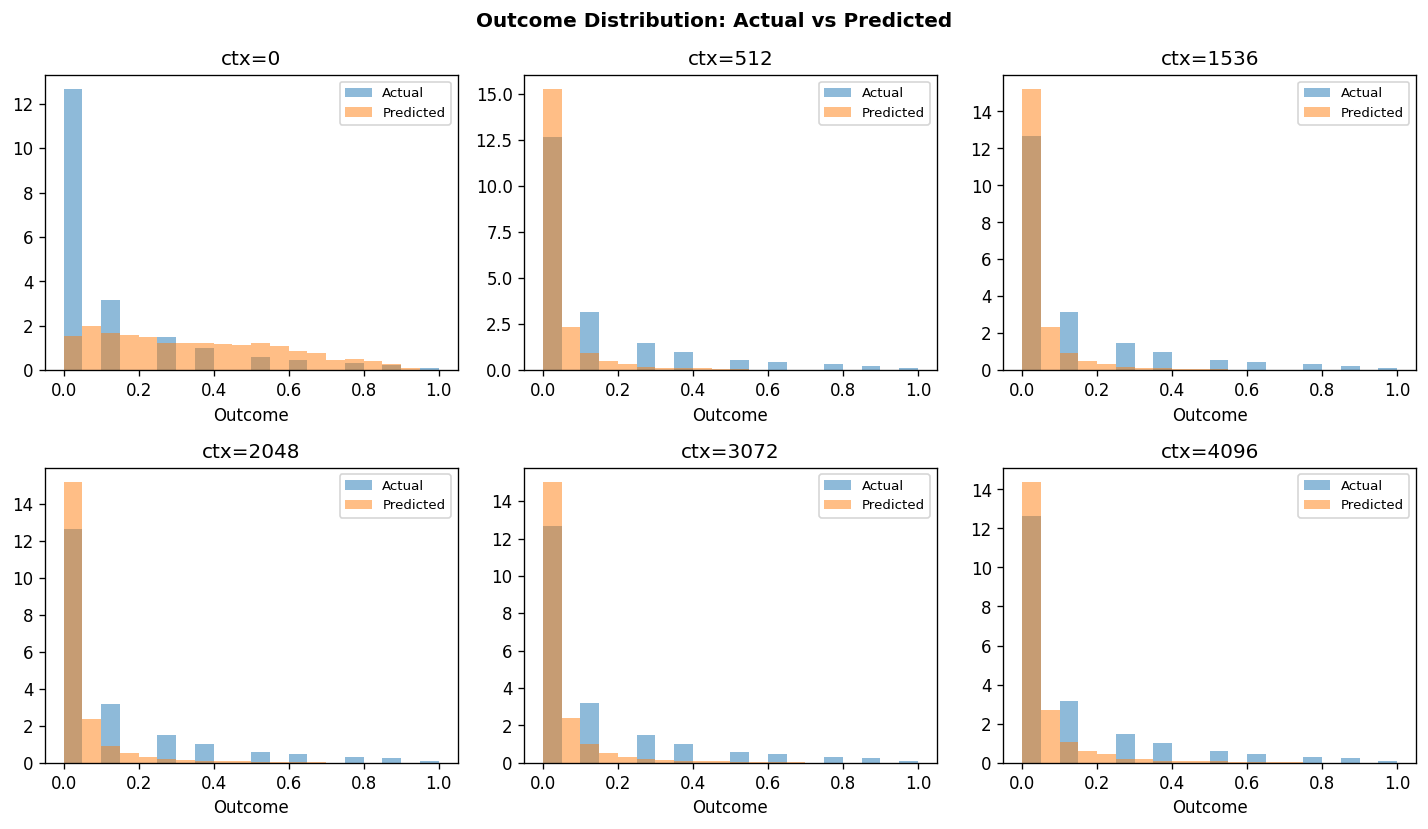

In [9]:
sub = df[df["horizon"] == 0]
contexts = sorted(sub["context"].unique())
if len(contexts) > 6:
    idx = np.linspace(0, len(contexts) - 1, 6, dtype=int)
    contexts = [contexts[i] for i in idx]

n = len(contexts)
cols = min(n, 3)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows), squeeze=False)
bins = np.linspace(0, 1, 21)
for i, c in enumerate(contexts):
    ax = axes[i // cols][i % cols]
    d = sub[sub["context"] == c]
    ax.hist(d["actual"], bins=bins, alpha=0.5, label="Actual", density=True)
    ax.hist(d["predicted"], bins=bins, alpha=0.5, label="Predicted", density=True)
    ax.set_title(f"ctx={c}")
    ax.set_xlabel("Outcome")
    ax.legend(fontsize=8)
for i in range(n, rows * cols):
    axes[i // cols][i % cols].set_visible(False)
fig.suptitle("Outcome Distribution: Actual vs Predicted", fontweight="bold")
fig.tight_layout()

## Attention analysis: what token types does the model attend to?

In [10]:
import json
import uuid
import requests

SERVER = "http://localhost:8000"
HISTORY = "../checkpoints/history.json"
CONTEXT_SIZE = 512  # number of (task, outcome) pairs to register

# Load trajectory
with open(HISTORY) as f:
    traj = json.load(f)

# Pick a target task (first eval task not in context)
TARGET_TASK = traj["tasks"][CONTEXT_SIZE]

# Register a learner with context
learner_id = str(uuid.uuid4())
requests.post(f"{SERVER}/learners", json={
    "learner_id": learner_id,
    "tasks": traj["tasks"][:CONTEXT_SIZE],
    "outcomes": traj["outcomes"][:CONTEXT_SIZE],
    "answers": traj["answers"][:CONTEXT_SIZE] if "answers" in traj else None,
}).raise_for_status()

# Get attention weights with target task
resp = requests.post(f"{SERVER}/attention", json={
    "learner_id": learner_id,
    "target_task": TARGET_TASK,
})
resp.raise_for_status()
attn = resp.json()

# Cleanup
requests.delete(f"{SERVER}/learners/{learner_id}")

print(f"Sequence length: {attn['seq_len']} tokens, {attn['n_layers']} layers, {attn['n_heads']} heads")
print(f"Target task: {TARGET_TASK[:80]}")
print(f"Token type counts: BOS={attn['token_types'].count(0)}, "
      f"TASK={attn['token_types'].count(1)}, "
      f"OUTCOME={attn['token_types'].count(2)}, "
      f"ANSWER={attn['token_types'].count(3)}")

ConnectionError: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /learners (Caused by NewConnectionError("HTTPConnection(host='localhost', port=8000): Failed to establish a new connection: [Errno 111] Connection refused"))

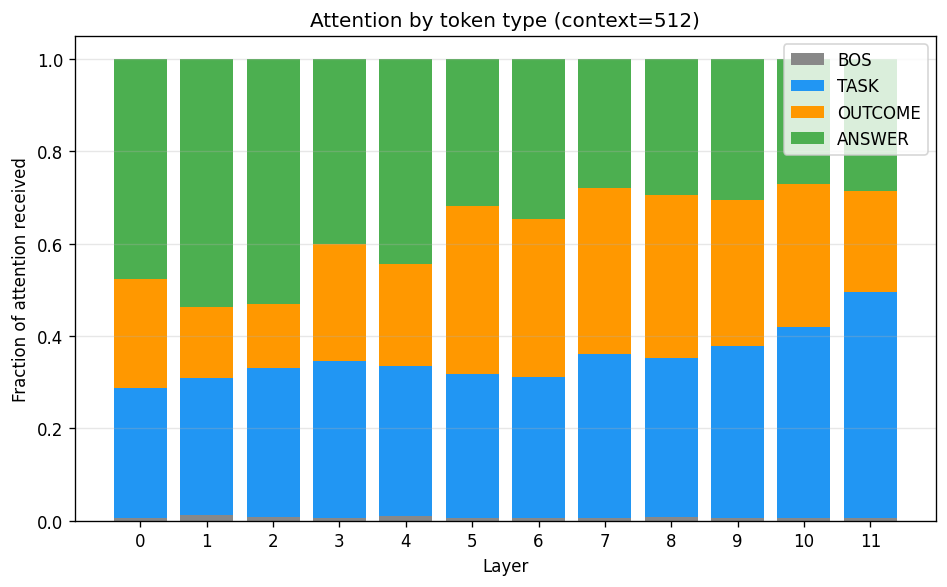

In [ ]:
# Plot: fraction of attention received by each token type, per layer
fig, ax = plt.subplots(figsize=(8, 5))

layers = list(range(attn["n_layers"]))
bottom = np.zeros(len(layers))
colors = {"BOS": "#888888", "TASK": "#2196F3", "OUTCOME": "#FF9800", "ANSWER": "#4CAF50"}

for type_name in ["BOS", "TASK", "OUTCOME", "ANSWER"]:
    vals = attn["attn_by_type"].get(type_name, [0] * len(layers))
    ax.bar(layers, vals, bottom=bottom, label=type_name, color=colors[type_name])
    bottom += np.array(vals)

ax.set_xlabel("Layer")
ax.set_ylabel("Fraction of attention received")
ax.set_title(f"Attention by token type (context={CONTEXT_SIZE})")
ax.legend()
ax.set_xticks(layers)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

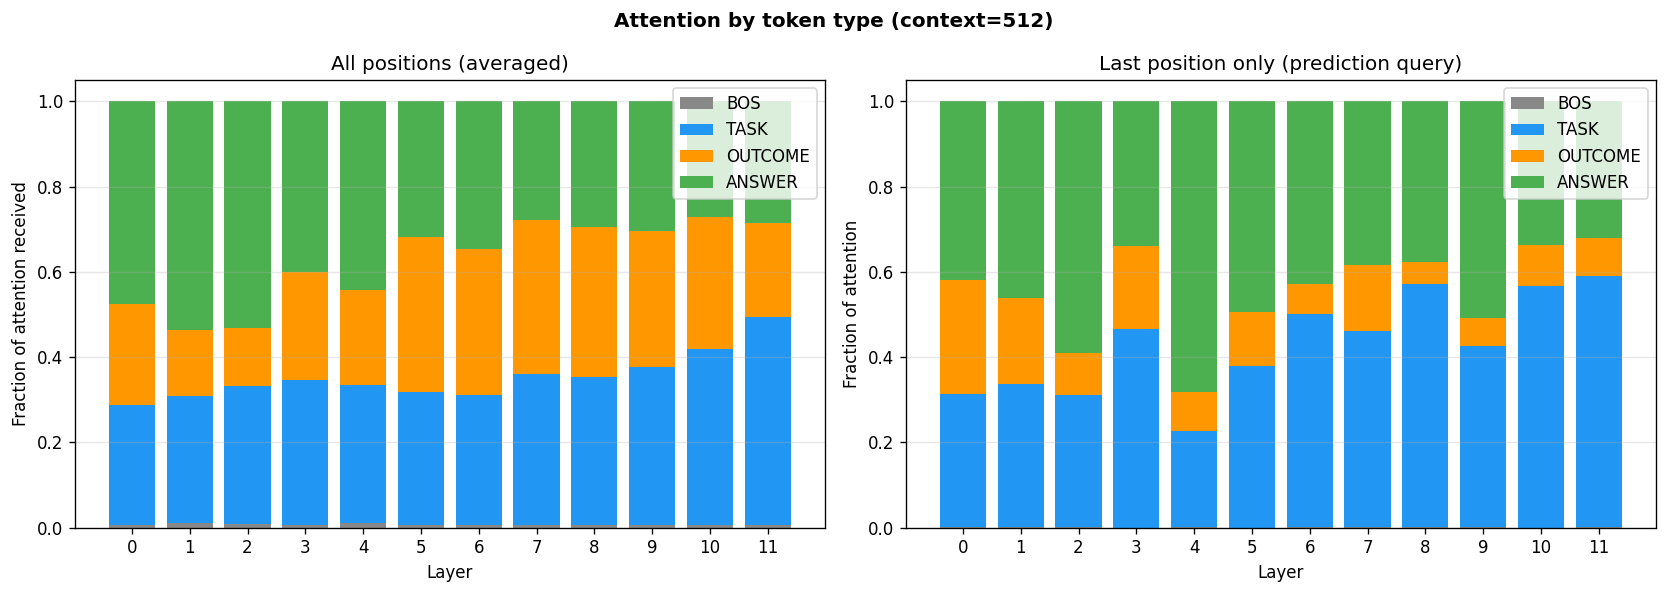

In [ ]:
# Attention from the LAST position only (the prediction position)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

layers = list(range(attn["n_layers"]))
colors = {"BOS": "#888888", "TASK": "#2196F3", "OUTCOME": "#FF9800", "ANSWER": "#4CAF50"}

# Left: all positions (same as above)
bottom = np.zeros(len(layers))
for type_name in ["BOS", "TASK", "OUTCOME", "ANSWER"]:
    vals = attn["attn_by_type"].get(type_name, [0] * len(layers))
    ax1.bar(layers, vals, bottom=bottom, label=type_name, color=colors[type_name])
    bottom += np.array(vals)
ax1.set_xlabel("Layer")
ax1.set_ylabel("Fraction of attention received")
ax1.set_title("All positions (averaged)")
ax1.legend()
ax1.set_xticks(layers)
ax1.grid(axis="y", alpha=0.3)

# Right: last position only
bottom = np.zeros(len(layers))
for type_name in ["BOS", "TASK", "OUTCOME", "ANSWER"]:
    vals = attn["last_pos_attn_by_type"].get(type_name, [0] * len(layers))
    ax2.bar(layers, vals, bottom=bottom, label=type_name, color=colors[type_name])
    bottom += np.array(vals)
ax2.set_xlabel("Layer")
ax2.set_ylabel("Fraction of attention")
ax2.set_title("Last position only (prediction query)")
ax2.legend()
ax2.set_xticks(layers)
ax2.grid(axis="y", alpha=0.3)

fig.suptitle(f"Attention by token type (context={CONTEXT_SIZE})", fontweight="bold")
fig.tight_layout()

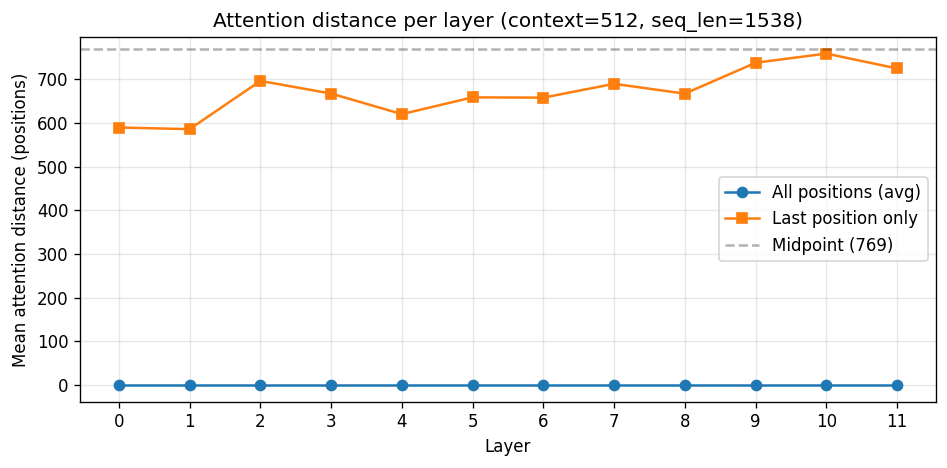

In [ ]:
# How far back does attention look?
fig, ax = plt.subplots(figsize=(8, 4))

layers = list(range(attn["n_layers"]))
ax.plot(layers, attn["mean_attn_distance"], "o-", label="All positions (avg)")
ax.plot(layers, attn["last_pos_attn_distance"], "s-", label="Last position only")
ax.axhline(attn["seq_len"] / 2, color="k", ls="--", alpha=0.3, label=f"Midpoint ({attn['seq_len']//2})")
ax.set_xlabel("Layer")
ax.set_ylabel("Mean attention distance (positions)")
ax.set_title(f"Attention distance per layer (context={CONTEXT_SIZE}, seq_len={attn['seq_len']})")
ax.legend()
ax.set_xticks(layers)
ax.grid(alpha=0.3)
fig.tight_layout()

## Interactive: attention from prediction position to context (hover for details)

In [ ]:
import plotly.graph_objects as go

weights = np.array(attn["last_pos_attn_per_position"])
types = attn["token_types"]
labels = attn["token_labels"]

# Build hover text with full label and attention weight
type_map = {0: "BOS", 1: "TASK", 2: "OUTCOME", 3: "ANSWER"}
type_colors = {0: "#888888", 1: "#2196F3", 2: "#FF9800", 3: "#4CAF50"}
hover_texts = []
bar_colors = []
for i, (lbl, w, t) in enumerate(zip(labels, weights, types)):
    hover_texts.append(f"pos {i} ({type_map[t]})<br>{lbl}<br>attention: {w:.6f}")
    # Last position (target) gets a distinct color
    if lbl.startswith("TARGET:"):
        bar_colors.append("#E91E63")
    else:
        bar_colors.append(type_colors[t])

fig = go.Figure()
fig.add_trace(go.Bar(
    x=list(range(len(weights))),
    y=weights,
    marker=dict(color=bar_colors),
    hovertext=hover_texts,
    hoverinfo="text",
))

fig.update_layout(
    title=f"Attention from target task to context (context={CONTEXT_SIZE})<br>"
          f"<sub>Target: {TARGET_TASK[:80]}</sub>",
    xaxis_title="Position in sequence",
    yaxis_title="Attention weight",
    height=450,
    hoverlabel=dict(font_size=12),
)
fig.show()

## Confusion matrix: Easy / Medium / Hard classification

Actual distribution:
  Hard: 12390 (79.2%)
  Medium: 2992 (19.1%)
  Easy: 269 (1.7%)


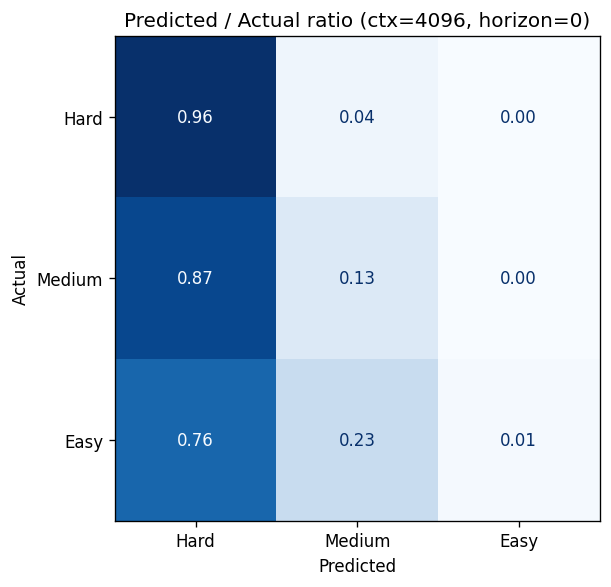

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def categorize(values, thresholds=(0.2, 0.8)):
    cats = []
    for v in values:
        if v <= thresholds[0]:
            cats.append("Hard")
        elif v <= thresholds[1]:
            cats.append("Medium")
        else:
            cats.append("Easy")
    return cats

sub = df[(df["horizon"] == 0) & (df["context"] == df["context"].max())]
ctx_val = int(sub["context"].iloc[0])

true_cats = categorize(sub["actual"])
pred_cats = categorize(sub["predicted"])
labels = ["Hard", "Medium", "Easy"]

# Print actual distribution
from collections import Counter
dist = Counter(true_cats)
total = len(true_cats)
print("Actual distribution:")
for l in labels:
    print(f"  {l}: {dist[l]} ({dist[l]/total:.1%})")

# Confusion matrix: count_predicted / count_actual
cm = confusion_matrix(true_cats, pred_cats, labels=labels)
row_totals = cm.sum(axis=1, keepdims=True)
cm_ratio = cm / row_totals

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_ratio, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Predicted / Actual ratio (ctx={ctx_val}, horizon=0)")
fig.tight_layout()